# Zadaća: Faktorizacijski model za preporuku knjiga
**Studentica:** Emina Skopljak  
**Dataset:** Book Recommendation Dataset (Kaggle)

Cilj ove zadaće je implementirati sistem preporuka za knjige koristeći **NMF (Non-negative Matrix Factorization)** algoritam.  
Prikazat ćemo originalnu sparse matricu, izvršiti faktorizaciju kako bismo naučili skrivene profile čitaoca, te na kraju generisati konkretne preporuke.

In [11]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
warnings.filterwarnings("ignore")

#učitavanje podataka
print("=== SISTEM PREPORUKA KNJIGA ===")

#učitavamo prvih 100.000 ocjena
df = pd.read_csv("Ratings.csv", nrows=100000)

print(f"Ukupno učitanih ocjena: {len(df)}")
print(f"Broj jedinstvenih čitaoca: {df['User-ID'].nunique()}")
print(f"Broj jedinstvenih knjiga (ISBN): {df['ISBN'].nunique()}")
print(f"Raspon ocjena: {df['Book-Rating'].min()} - {df['Book-Rating'].max()} (1 do 10)\n")

display(df.head())

=== SISTEM PREPORUKA KNJIGA ===
Ukupno učitanih ocjena: 100000
Broj jedinstvenih čitaoca: 9424
Broj jedinstvenih knjiga (ISBN): 63826
Raspon ocjena: 0 - 10 (1 do 10)



,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


## 1. Kreiranje Sparse matrice
Kako bismo primijenili faktorizaciju, pravimo matricu gdje su redovi **čitaoci**, a kolone **knjige**. 
Za vizualizaciju izdvajamo podskup od 15 najaktivnijih čitaoca i 15 najpopularnijih knjiga. Nepoznate ocjene su popunjene nulama (što matricu čini "šupljom" tj. Sparse).

In [12]:
#kreiranje sparse matrice
top_kupci = df['User-ID'].value_counts().head(15).index
top_knjige = df['ISBN'].value_counts().head(15).index

#filtriramo dataset samo na najaktivnije
df_sub = df[df['User-ID'].isin(top_kupci) & df['ISBN'].isin(top_knjige)]

#pravimo matricu
df_ocjene = df_sub.pivot_table(index='User-ID', columns='ISBN', values='Book-Rating')

#popunjavamo praznine sa nulama
ocjene = df_ocjene.fillna(0).values
kupci = [f"Čitaoc {uid}" for uid in df_ocjene.index]
knjige = [f"Knjiga {isbn[-4:]}" for isbn in df_ocjene.columns] # Uzimamo zadnja 4 broja ISBN-a radi ljepšeg prikaza

print(f"Dimenzije SPARSE matrice: {df_ocjene.shape} (čitaoci x knjige)")
print(f"Gustoća matrice: {np.count_nonzero(ocjene) / df_ocjene.size:.1%} (Ostalo su nule/šupljine)\n")

print("Prikaz šuplje matrice:")
display(df_ocjene.fillna(0).head())

Dimenzije SPARSE matrice: (14, 15) (čitaoci x knjige)
Gustoća matrice: 16.7% (Ostalo su nule/šupljine)

Prikaz šuplje matrice:


ISBN,0060928336,0060930535,0142001740,0156027321,0312195516,0316666343,0375727345,0385504209,0440214041,0446672211,059035342X,067976402X,0679781587,0804106304,0971880107
User-ID,,,,,,,,,,,,,,,
3363,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0
6251,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0
6575,8.0,0.0,8.0,0.0,8.0,0.0,0.0,0.0,0.0,8.0,0.0,7.0,9.0,9.0,0.0
7346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0
11601,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. NMF Faktorizacija matrice
Koristimo *Non-negative Matrix Factorization* (NMF) algoritam sa 4 skrivene komponente. On rastavlja šuplju matricu $R$ na matrice $W$ (profil čitaoca) i $H$ (profil knjige).

In [13]:
#NMF FAKTORIZACIJA
print("Pokrećem NMF faktorizaciju...")

nmf_model = NMF(n_components=4, init="random", random_state=42, max_iter=500)

W = nmf_model.fit_transform(ocjene) # Profil čitaoca
H = nmf_model.components_           # Profil knjige

print("=== FAKTORIZACIJA ZAVRŠENA ===")
print(f"Greška rekonstrukcije: {nmf_model.reconstruction_err_:.4f}")

Pokrećem NMF faktorizaciju...
=== FAKTORIZACIJA ZAVRŠENA ===
Greška rekonstrukcije: 20.5517


## 3. Rekonstrukcija matrice i vizualizacija
Množenjem naučenih matrica ($W \times H$) dobijamo novu matricu u kojoj više nema nula – svako prazno polje je popunjeno predviđenom ocjenom!

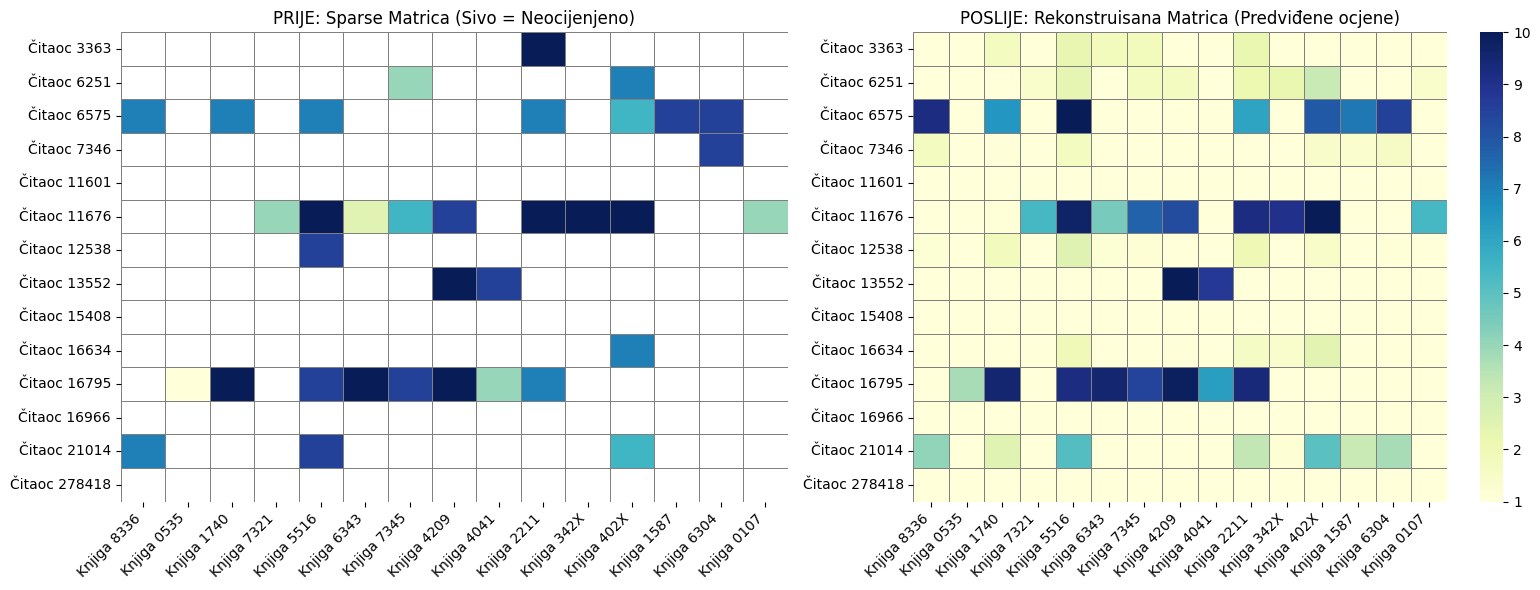

In [14]:
#REKONSTRUISANA (POPUNJENA) MATRICA
R_pred = np.dot(W, H)
R_pred = np.clip(R_pred, 1, 10) # Ocjene su od 1 do 10
df_rekonstruisana = pd.DataFrame(R_pred, index=kupci, columns=knjige).round(2)

#VIZUALIZACIJA (SPARSE VS REKONSTRUISANA)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#lijeva slika (SPARSE)
sparse_prikaz = ocjene.copy().astype(float)
sparse_prikaz[sparse_prikaz == 0] = np.nan
sns.heatmap(sparse_prikaz, ax=axes[0], cmap="YlGnBu", cbar=False, linewidths=0.5, linecolor='gray', facecolor='lightgray')
axes[0].set_title("PRIJE: Sparse Matrica (Sivo = Neocijenjeno)")
axes[0].set_xticklabels(knjige, rotation=45, ha="right")
axes[0].set_yticklabels(kupci, rotation=0)

#desna slika (POSLIJE)
sns.heatmap(R_pred, ax=axes[1], cmap="YlGnBu", cbar=True, linewidths=0.5, linecolor='gray')
axes[1].set_title("POSLIJE: Rekonstruisana Matrica (Predviđene ocjene)")
axes[1].set_xticklabels(knjige, rotation=45, ha="right")
axes[1].set_yticklabels(kupci, rotation=0)

plt.tight_layout()
plt.show()

## 4. Sistem preporuka (Konačni rezultati)
Sada iz rekonstruisane matrice uzimamo predviđene visoke ocjene za knjige koje čitaoci još nisu čitali, i nudimo im top 3 preporuke.

In [15]:
#generisanje preporuka
print("=" * 60)
print(" TOP 3 PREPORUKE KNJIGA ZA ČITAOCE")
print("=" * 60)

for i in range(5): 
    #tamo gdje su nule u originalu, to znači da korisnik nije čitao knjigu
    neocjenjene = np.where(ocjene[i] == 0)[0]
    
    if len(neocjenjene) == 0:
        continue
        
    #uzimamo predviđene ocjene i sortiramo ih
    predvidjene = [(knjige[j], R_pred[i, j]) for j in neocjenjene]
    predvidjene.sort(key=lambda x: x[1], reverse=True)
    
    top3 = predvidjene[:3]
    preporuke = ", ".join([f"{k} (Ocjena: {o:.1f})" for k, o in top3])
    
    print(f"\n{kupci[i]} bi trebao/la pročitati: \n -> {preporuke}")

 TOP 3 PREPORUKE KNJIGA ZA ČITAOCE

Čitaoc 3363 bi trebao/la pročitati: 
 -> Knjiga 5516 (Ocjena: 2.3), Knjiga 7345 (Ocjena: 1.8), Knjiga 6343 (Ocjena: 1.8)

Čitaoc 6251 bi trebao/la pročitati: 
 -> Knjiga 5516 (Ocjena: 2.3), Knjiga 342X (Ocjena: 2.3), Knjiga 2211 (Ocjena: 2.1)

Čitaoc 6575 bi trebao/la pročitati: 
 -> Knjiga 0535 (Ocjena: 1.0), Knjiga 7321 (Ocjena: 1.0), Knjiga 6343 (Ocjena: 1.0)

Čitaoc 7346 bi trebao/la pročitati: 
 -> Knjiga 5516 (Ocjena: 1.7), Knjiga 8336 (Ocjena: 1.7), Knjiga 402X (Ocjena: 1.5)

Čitaoc 11601 bi trebao/la pročitati: 
 -> Knjiga 8336 (Ocjena: 1.0), Knjiga 0535 (Ocjena: 1.0), Knjiga 1740 (Ocjena: 1.0)
